In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

In [242]:
def exp_func(lmbd, p):
    return -1 / lmbd * np.log(p)

def generate_request_time_exp(lmbd, work_time):
    T_server = [0]
    while True:
        new_t = T_server[-1] + exp_func(lmbd, np.random.rand())
        if new_t > work_time:
            break
        T_server.append(new_t)
    T_server.pop(0)
    return np.asarray(T_server)

def generate_process_time_exp(lmbd, n):
    return exp_func(lmbd, np.random.rand(n))

def simulate(Ts, Tz, T, m):
    processed_signals = 0
    last_start = 0
    last_end = 0
    work_times = [0] * (m + 2)
    buf = deque()
    for i in range(len(Ts)):
        while len(buf) != 0 and last_end <= Ts[i]:
            work_times[len(buf) + 1] += last_end - last_start
            last_start = last_end
            last_end += buf.popleft()
            processed_signals += 1
        
        if last_end <= Ts[i]:
            work_times[0] += Ts[i] - last_end
            work_times[1] += last_end - last_start
            last_start = Ts[i]
            last_end = last_start + Tz[i]
            processed_signals += 1

        elif len(buf) < m:
            work_times[len(buf) + 1] += Ts[i] - last_start
            last_start = Ts[i]
            buf.append(Tz[i])
    
    # Очистка буффера в конце
    while len(buf) != 0:
            work_times[len(buf) + 1] += last_end - last_start
            last_start = last_end
            last_end += buf.popleft()
            processed_signals += 1
    # Время последней заявки
    work_times[1] += last_end - last_start

    work_times[0] += max(0, T - np.sum(work_times))

    return processed_signals, work_times

def task_123(lmbd, mu, T, m):
    # Теория
    ro = lmbd / mu
    P0 = 1 / (np.sum(ro**np.arange(m + 2)))
    P1 = ro * P0
    P2 = ro**2 * P0
    P3 = ro**3 * P0
    L = P2 * 1 + P3 * 2
    print(f"Среднее число заявок в накопителе (Теор): {L}")
    # print(f"10%: [{L * 0.9}: {L * 1.1}]")

    # Симуляция
    n = 10
    means = []
    for _ in range(n):
        T_req = generate_request_time_exp(lmbd, T)
        T_processing = generate_process_time_exp(mu, len(T_req))

        processed_signals, work_times = simulate(T_req, T_processing, T, m)
        # print(work_times[0] / np.sum(work_times))

        acc_time = np.insert(np.arange(m + 1), 0, 0)
        mean_in_acc = sum(acc_time * work_times) / np.sum(work_times)
        means.append(mean_in_acc)
    print(f"Среднее число заявок в накопителе (Сим): {np.mean(means)}")

    means.append(np.mean(means))
    means.append(L)
    
    table_rows = list(range(1, 11))
    table_rows.extend(["M", "Theor"])
    df = pd.DataFrame(means, columns=["L"], index=table_rows)
    return df

In [243]:
# Вариант 1
m1 = 2
lmbd1 = 0.5
mu1 = 0.4
T = 1000

df = task_123(lmbd1, mu1, T, m1)
print(df)

Среднее число заявок в накопителе (Теор): 0.948509485094851
Среднее число заявок в накопителе (Сим): 0.9299084766884089
              L
1      0.799969
2      1.096767
3      0.935804
4      0.860775
5      0.939543
6      0.864674
7      0.984644
8      1.028247
9      0.913480
10     0.875182
M      0.929908
Theor  0.948509


In [244]:
# Вариант 2
m2 = 2
lmbd2 = 1
mu2 = 0.4
T = 1000

task_123(lmbd2, mu2, T, m2)

Среднее число заявок в накопителе (Теор): 1.477832512315271
Среднее число заявок в накопителе (Сим): 1.4478169327048565


,L
1,1.484899
2,1.394356
3,1.445006
4,1.439858
5,1.494368
6,1.417096
7,1.430178
8,1.404918
9,1.481443
10,1.486048


In [245]:
# Вариант 3
m1 = 2
lmbd1 = 4
mu1 = 0.4
T = 1000

task_123(lmbd1, mu1, T, m1)

Среднее число заявок в накопителе (Теор): 1.8901890189018902
Среднее число заявок в накопителе (Сим): 1.8810852925787873


,L
1,1.852953
2,1.885227
3,1.889012
4,1.885406
5,1.873816
6,1.888731
7,1.883280
8,1.880481
9,1.888202
10,1.883744


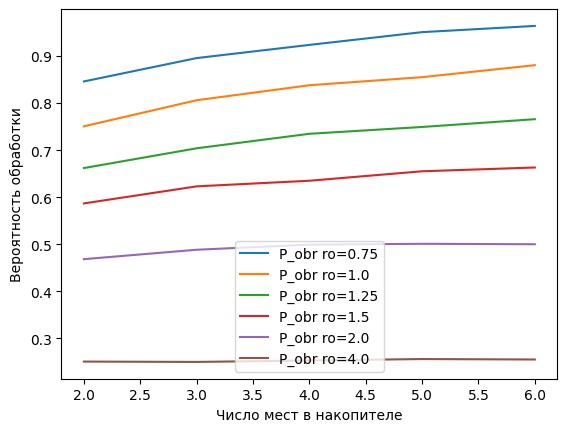

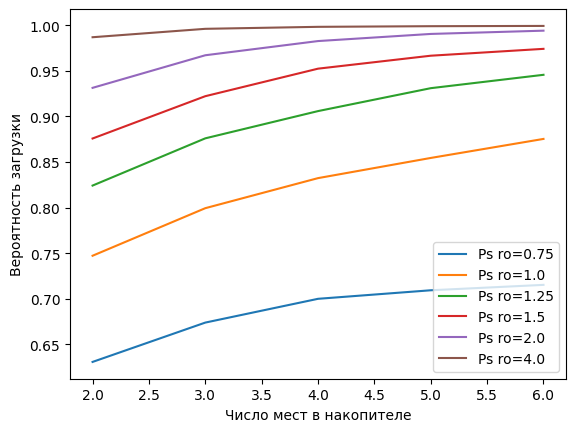

In [271]:
mu4 = 0.4
T = 1000
ros = [0.75, 1.0, 1.25, 1.5, 2.0, 4.0]
ms = range(2, 7)

all_ps = [[] for _ in range(len(ros))]
all_pw = [[] for _ in range(len(ros))]

for m in ms:
    for ro_idx in range(len(ros)):
        ro = ros[ro_idx]
        lmbd = ro * mu4

        n = 100
        pss = []
        pws = []
        for _ in range(n):
            T_req = generate_request_time_exp(lmbd, T)
            T_processing = generate_process_time_exp(mu4, len(T_req))
            processed_signals, work_times = simulate(T_req, T_processing, T, m)
            pss.append(processed_signals / len(T_req))
            pws.append(np.sum(work_times[1:]) / np.sum(work_times))
        all_ps[ro_idx].append(np.mean(pss))
        all_pw[ro_idx].append(np.mean(pws))

for i in range(len(ros)):
    plt.plot(ms, all_ps[i], label=f'P_obr ro={ros[i]}')
plt.xlabel("Число мест в накопителе")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.show()

for i in range(len(ros)):
    plt.plot(ms, all_pw[i], label=f'Ps ro={ros[i]}')
plt.xlabel("Число мест в накопителе")
plt.ylabel("Вероятность загрузки")
plt.legend()
plt.show()

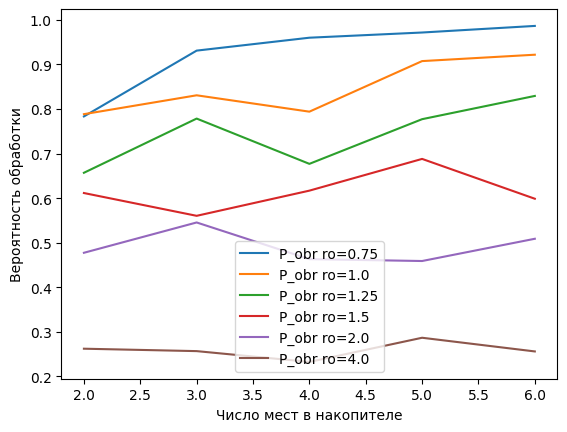

In [250]:
for i in range(len(ros)):
    plt.plot(ms, all_ps[i], label=f'P_obr ro={ros[i]}')
plt.xlabel("Число мест в накопителе")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.show()

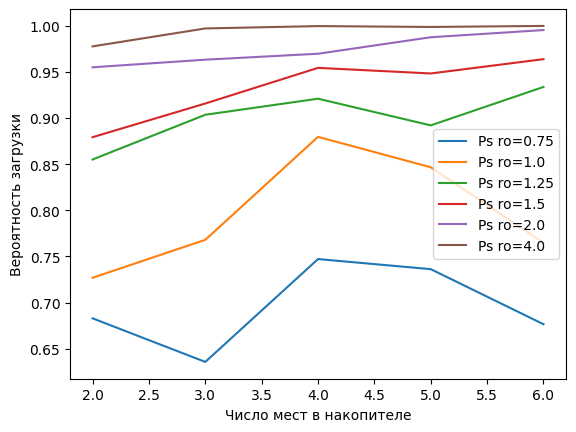

In [260]:
for i in range(len(ros)):
    plt.plot(ms, all_pw[i], label=f'Ps ro={ros[i]}')
plt.xlabel("Число мест в накопителе")
plt.ylabel("Вероятность загрузки")
plt.legend()
plt.show()